In this model lets find the expected Outcome 

Step 1: Lets import all the necessary libraries

In [1]:
# Install missing package(s) in the notebook environment
%pip install ta --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from binance.client import Client
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import ta
import warnings
warnings.filterwarnings('ignore')

# Make plots look better
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 8)

print("✅ All libraries imported successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!


Step 2 : Connect to ur binance api server sor any api key 

In [ ]:
# 🔐 REPLACE WITH YOUR API KEYS:
api_key = "Api_key"
secret_key = "Secret_Key"


client = Client(api_key, secret_key)
print("✅ Connected to Binance API")

✅ Connected to Binance API


Step 3 : download the required historical data

In [4]:
def download_crypto_data(symbol="BTCUSDT", interval="1d", lookback="3 years ago UTC"):
    """Download cryptocurrency data from Binance"""
    
    print(f"📥 Downloading {symbol} data...")
    
    klines = client.get_historical_klines(symbol, interval, lookback)
    
    data = pd.DataFrame(klines, columns=[
        "Time", "Open", "High", "Low", "Close", "Volume",
        "CloseTime", "QuoteVolume", "Trades",
        "TakerBuyBase", "TakerBuyQuote", "Ignore"
    ])
    
    # Convert to proper types
    data["Close"] = data["Close"].astype(float)
    data["Open"] = data["Open"].astype(float)
    data["High"] = data["High"].astype(float)
    data["Low"] = data["Low"].astype(float)
    data["Volume"] = data["Volume"].astype(float)
    data["Time"] = pd.to_datetime(data["Time"], unit="ms")
    
    # Keep only necessary columns
    data = data[["Time", "Open", "High", "Low", "Close", "Volume"]]
    
    print(f"✅ Downloaded {len(data)} rows of data")
    print(f"📅 Date range: {data['Time'].min()} to {data['Time'].max()}")
    
    return data

# Download data
data = download_crypto_data("BTCUSDT", "1d", "3 years ago UTC")

# Preview
print("\n📊 First few rows:")
data.head()

📥 Downloading BTCUSDT data...
✅ Downloaded 1096 rows of data
📅 Date range: 2023-02-21 00:00:00 to 2026-02-20 00:00:00

📊 First few rows:


,Time,Open,High,Low,Close,Volume
0,2023-02-21,24843.89,25250.00,24148.34,24452.16,376000.82868
1,2023-02-22,24450.67,24476.05,23574.69,24182.21,379425.75365
2,2023-02-23,24182.21,24599.59,23608.00,23940.20,398400.45437
3,2023-02-24,23940.20,24132.35,22841.19,23185.29,343582.57453
4,2023-02-25,23184.04,23219.13,22722.00,23157.07,191311.81010


Step 4: Get the chart of the given data 

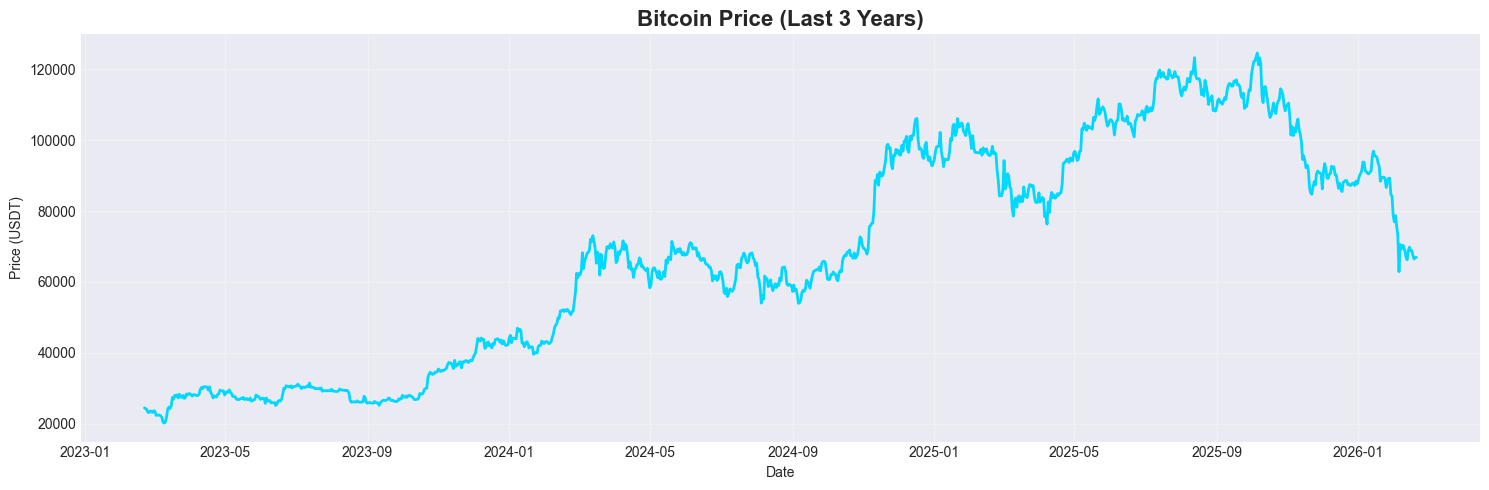

💰 Current Price: $66,926.43
📈 Highest Price: $124,658.54
📉 Lowest Price: $20,150.69


In [5]:
plt.figure(figsize=(15, 5))
plt.plot(data['Time'], data['Close'], linewidth=2, color='#00d9ff')
plt.title('Bitcoin Price (Last 3 Years)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💰 Current Price: ${data['Close'].iloc[-1]:,.2f}")
print(f"📈 Highest Price: ${data['Close'].max():,.2f}")
print(f"📉 Lowest Price: ${data['Close'].min():,.2f}")